In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import sklearn
import skimage

print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Scikit-image:", skimage.__version__)

Python: d:\AI\projects\project_02_signature_verification_structure\project_02_signature_verification\.venv\Scripts\python.exe
NumPy: 2.2.6
Pandas: 3.0.5
OpenCV: 5.0.0
Scikit-learn: 1.9.1
Scikit-image: 0.26.0


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
UTSIG_DIR = RAW_DIR / "utsig"

print("Project Root :" ,  PROJECT_ROOT)
print("UTSIG Directory : " , UTSIG_DIR)
print("EXISTS : " , UTSIG_DIR.exists())

Project Root : d:\AI\projects\project_02_signature_verification_structure\project_02_signature_verification
UTSIG Directory :  d:\AI\projects\project_02_signature_verification_structure\project_02_signature_verification\data\raw\utsig
EXISTS :  True


In [3]:
VALID_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}

image_files = [
    f
    for f in UTSIG_DIR.rglob("*")
    if (
        f.is_file()
        and f.suffix.lower() in VALID_EXTENSIONS
        and "__MACOSX" not in f.parts
    )
]

print("Valid Image Files:", len(image_files))

Valid Image Files: 8279


In [4]:
for f in image_files[:10] :
  print(f.name)

11.tif
12.tif
13.tif
14.tif
15.tif
16.tif
21.tif
22.tif
23.tif
24.tif


In [5]:
extensions = pd.Series([f.suffix.lower() for f in image_files])
print(extensions.value_counts())

.tif    8279
Name: count, dtype: int64


In [6]:
for f in image_files[:10]:
    print(f.relative_to(UTSIG_DIR))

UTSig_FullSize\UTSig_FullSize\Forgery\Simple\1\11.tif
UTSig_FullSize\UTSig_FullSize\Forgery\Simple\1\12.tif
UTSig_FullSize\UTSig_FullSize\Forgery\Simple\1\13.tif
UTSig_FullSize\UTSig_FullSize\Forgery\Simple\1\14.tif
UTSig_FullSize\UTSig_FullSize\Forgery\Simple\1\15.tif
UTSig_FullSize\UTSig_FullSize\Forgery\Simple\1\16.tif
UTSig_FullSize\UTSig_FullSize\Forgery\Simple\1\21.tif
UTSig_FullSize\UTSig_FullSize\Forgery\Simple\1\22.tif
UTSig_FullSize\UTSig_FullSize\Forgery\Simple\1\23.tif
UTSig_FullSize\UTSig_FullSize\Forgery\Simple\1\24.tif


In [7]:
top_level_dirs = [
  p for p in UTSIG_DIR.iterdir()
  if p.is_dir()
]

print("Top Level directories :" , len(top_level_dirs))

for d in top_level_dirs:
  print(d.name)

Top Level directories : 1
UTSig_FullSize


In [8]:
for f in image_files[:20]:
    print(
        "File:", f.name,
        "| Parent:", f.parent.name,
        "| Parent-2:", f.parent.parent.name
    )

File: 11.tif | Parent: 1 | Parent-2: Simple
File: 12.tif | Parent: 1 | Parent-2: Simple
File: 13.tif | Parent: 1 | Parent-2: Simple
File: 14.tif | Parent: 1 | Parent-2: Simple
File: 15.tif | Parent: 1 | Parent-2: Simple
File: 16.tif | Parent: 1 | Parent-2: Simple
File: 21.tif | Parent: 1 | Parent-2: Simple
File: 22.tif | Parent: 1 | Parent-2: Simple
File: 23.tif | Parent: 1 | Parent-2: Simple
File: 24.tif | Parent: 1 | Parent-2: Simple
File: 25.tif | Parent: 1 | Parent-2: Simple
File: 26.tif | Parent: 1 | Parent-2: Simple
File: 31.tif | Parent: 1 | Parent-2: Simple
File: 32.tif | Parent: 1 | Parent-2: Simple
File: 33.tif | Parent: 1 | Parent-2: Simple
File: 34.tif | Parent: 1 | Parent-2: Simple
File: 35.tif | Parent: 1 | Parent-2: Simple
File: 36.tif | Parent: 1 | Parent-2: Simple
File: 41.tif | Parent: 1 | Parent-2: Simple
File: 42.tif | Parent: 1 | Parent-2: Simple


In [9]:
folder_stats = []

for folder in top_level_dirs:
    count = len([
        f for f in folder.rglob("*")
        if f.is_file()
        and f.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]
    ])

    folder_stats.append({
        "folder": folder.name,
        "image_count": count
    })

folder_stats_df = pd.DataFrame(folder_stats)

folder_stats_df

,folder,image_count
0,UTSig_FullSize,16559


In [10]:
folder_stats_df.sort_values(
    "image_count",
    ascending=False
).head(30)

,folder,image_count
0,UTSig_FullSize,16559


In [11]:
UTSIG_DATASET_DIR = (
    UTSIG_DIR
    / "UTSig_FullSize"
    / "UTSig_FullSize"
)

GENUINE_DIR = UTSIG_DATASET_DIR / "Genuine"

SIMPLE_FORGERY_DIR = (
    UTSIG_DATASET_DIR
    / "Forgery"
    / "Simple"
)

SKILLED_FORGERY_DIR = (
    UTSIG_DATASET_DIR
    / "Forgery"
    / "Skilled"
)

print("Dataset Root :", UTSIG_DATASET_DIR)
print("Genuine      :", GENUINE_DIR.exists())
print("Simple       :", SIMPLE_FORGERY_DIR.exists())
print("Skilled      :", SKILLED_FORGERY_DIR.exists())

Dataset Root : d:\AI\projects\project_02_signature_verification_structure\project_02_signature_verification\data\raw\utsig\UTSig_FullSize\UTSig_FullSize
Genuine      : True
Simple       : True
Skilled      : True


In [12]:
def count_image(directory):
  return len([
    file for file in directory.rglob("*")
    if(
      file.is_file()
      and file.suffix.lower() in VALID_EXTENSIONS
      and "__MACOSX" not in file.parts
    )
  ])
  
genuine_count = count_image(GENUINE_DIR)

simple_count = count_image(SIMPLE_FORGERY_DIR)

skilled_count = count_image(SKILLED_FORGERY_DIR)

print("Genuine Images        :", genuine_count)
print("Simple Forgery Images :", simple_count)
print("Skilled Forgery Images:", skilled_count)

print("Total : " , genuine_count + simple_count + skilled_count )

Genuine Images        : 3450
Simple Forgery Images : 4140
Skilled Forgery Images: 689
Total :  8279


In [13]:
metadata = []

def add_images_to_metadata(directory , signature_type , is_genuine):
  for writer_dir in directory.iterdir():
    #اینو دارم میزارم فقط برای اینکه خودم بهتر بدونم که پوشه نویسندکانم کجاست
    if not writer_dir.is_dir():
      continue
    
    #طبق دیتاست اسم هر پوشه آیدی همان نویسنده است فک کنم
    writer_id = writer_dir.name
    
    for image_path in writer_dir.iterdir():
      if not image_path.is_file():
        continue
      if image_path.suffix.lower() not in VALID_EXTENSIONS:
        continue
      
      metadata.append({
        "file_path" : str(image_path.relative_to(PROJECT_ROOT)),
        "file_name" : image_path.name,
        "writer_id" : int(writer_id),
        "signature_type" : signature_type,
        "is_genuine" : is_genuine
      })

In [14]:
add_images_to_metadata(
    GENUINE_DIR,
    signature_type="genuine",
    is_genuine=1
)

add_images_to_metadata(
    SIMPLE_FORGERY_DIR,
    signature_type="simple_forgery",
    is_genuine=0
)

add_images_to_metadata(
    SKILLED_FORGERY_DIR,
    signature_type="skilled_forgery",
    is_genuine=0
)

In [15]:
metadata_df = pd.DataFrame(metadata)

metadata_df.head(10)

,file_path,file_name,writer_id,signature_type,is_genuine
0,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,1.tif,1,genuine,1
1,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,10.tif,1,genuine,1
2,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,11.tif,1,genuine,1
3,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,12.tif,1,genuine,1
4,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,13.tif,1,genuine,1
5,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,14.tif,1,genuine,1
6,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,15.tif,1,genuine,1
7,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,16.tif,1,genuine,1
8,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,17.tif,1,genuine,1
9,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,18.tif,1,genuine,1


In [16]:
metadata_df.shape

(7934, 5)

In [17]:
metadata_df["signature_type"].value_counts()

signature_type
simple_forgery     4140
genuine            3105
skilled_forgery     689
Name: count, dtype: int64

In [18]:
metadata_df["writer_id"].nunique()

115

In [19]:
metadata_df.groupby(
  [
    "writer_id",
    "signature_type"
  ]
).size().head(21)

writer_id  signature_type 
1          genuine            27
           simple_forgery     36
           skilled_forgery     6
2          genuine            27
           simple_forgery     36
           skilled_forgery     6
3          genuine            27
           simple_forgery     36
           skilled_forgery     6
4          genuine            27
           simple_forgery     36
           skilled_forgery     5
5          genuine            27
           simple_forgery     36
           skilled_forgery     6
6          genuine            27
           simple_forgery     36
           skilled_forgery     6
7          genuine            27
           simple_forgery     36
           skilled_forgery     6
dtype: int64

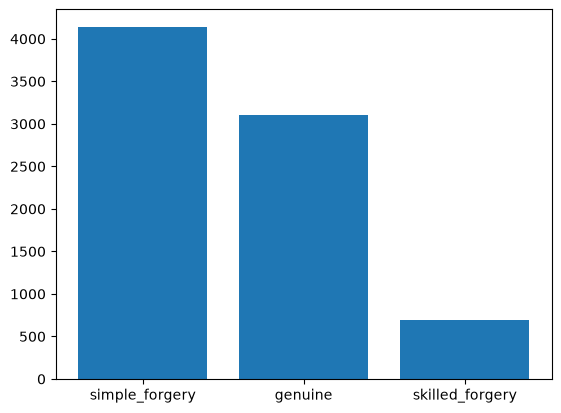

In [20]:
type_count = (
  metadata_df["signature_type"].value_counts()
)

plt.Figure(figsize=(9 , 5))

plt.bar(type_count.index , type_count.values)

plt.title = "UTSig Signature Type Distribution"

plt.xlabel = "Signature Types"
plt.ylabel = "Number of Images"

plt.show()

In [21]:
print(metadata_df.shape)

print(
    metadata_df[
        "signature_type"
    ].value_counts()
)

print(
    "Writers:",
    metadata_df[
        "writer_id"
    ].nunique()
)

metadata_df.groupby(
    [
        "writer_id",
        "signature_type"
    ]
).size().head(21)

(7934, 5)
signature_type
simple_forgery     4140
genuine            3105
skilled_forgery     689
Name: count, dtype: int64
Writers: 115


writer_id  signature_type 
1          genuine            27
           simple_forgery     36
           skilled_forgery     6
2          genuine            27
           simple_forgery     36
           skilled_forgery     6
3          genuine            27
           simple_forgery     36
           skilled_forgery     6
4          genuine            27
           simple_forgery     36
           skilled_forgery     5
5          genuine            27
           simple_forgery     36
           skilled_forgery     6
6          genuine            27
           simple_forgery     36
           skilled_forgery     6
7          genuine            27
           simple_forgery     36
           skilled_forgery     6
dtype: int64

In [22]:
writer_type_counts = (
  metadata_df.groupby("signature_type")["writer_id"].unique()
)

print(writer_type_counts)

signature_type
genuine            [1, 10, 100, 101, 102, 103, 104, 105, 106, 107...
simple_forgery     [1, 10, 100, 101, 102, 103, 104, 105, 106, 107...
skilled_forgery    [1, 10, 100, 101, 102, 103, 104, 105, 106, 107...
Name: writer_id, dtype: object


In [23]:
writer_stats = (
    metadata_df
    .groupby(
        [
            "writer_id",
            "signature_type"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

writer_stats.head(20)

signature_type,genuine,simple_forgery,skilled_forgery
writer_id,,,
1,27,36,6
2,27,36,6
3,27,36,6
4,27,36,5
5,27,36,6
6,27,36,6
7,27,36,6
8,27,36,6
9,27,36,6


In [24]:
writer_stats.describe()

signature_type,genuine,simple_forgery,skilled_forgery
count,115.0,115.0,115.000000
mean,27.0,36.0,5.991304
std,0.0,0.0,0.093250
min,27.0,36.0,5.000000
25%,27.0,36.0,6.000000
50%,27.0,36.0,6.000000
75%,27.0,36.0,6.000000
max,27.0,36.0,6.000000


In [25]:
corrupted_files = []

for _, row in metadata_df.iterrows():

    image_path = (
        PROJECT_ROOT
        / row["file_path"]
    )

    img = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        corrupted_files.append(
            str(image_path)
        )

print(
    "Corrupted images:",
    len(corrupted_files)
)

Corrupted images: 0


In [26]:
writer_id = 1

writer_sample = metadata_df[
  metadata_df["writer_id"] == writer_id
]

genuine_samples = writer_sample[
  writer_sample["signature_type"] == "genuine"
].sample(
  min(3 , len(
    writer_sample["signature_type"] == "genuine"
  ))
  ,
  random_state=42
)

simple_samples = writer_sample[
  writer_sample["signature_type"] == "simple_forgery"
].sample(
  min(3 , len(
    writer_sample["signature_type"] == "simple_forgery"
  ))
  ,
  random_state=42
)


skilled_samples = writer_sample[
  writer_sample["signature_type"] == "skilled_forgery"
].sample(
  min(3 , len(
    writer_sample["signature_type"] == "skilled_forgery"
  ))
  ,
  random_state=42
)

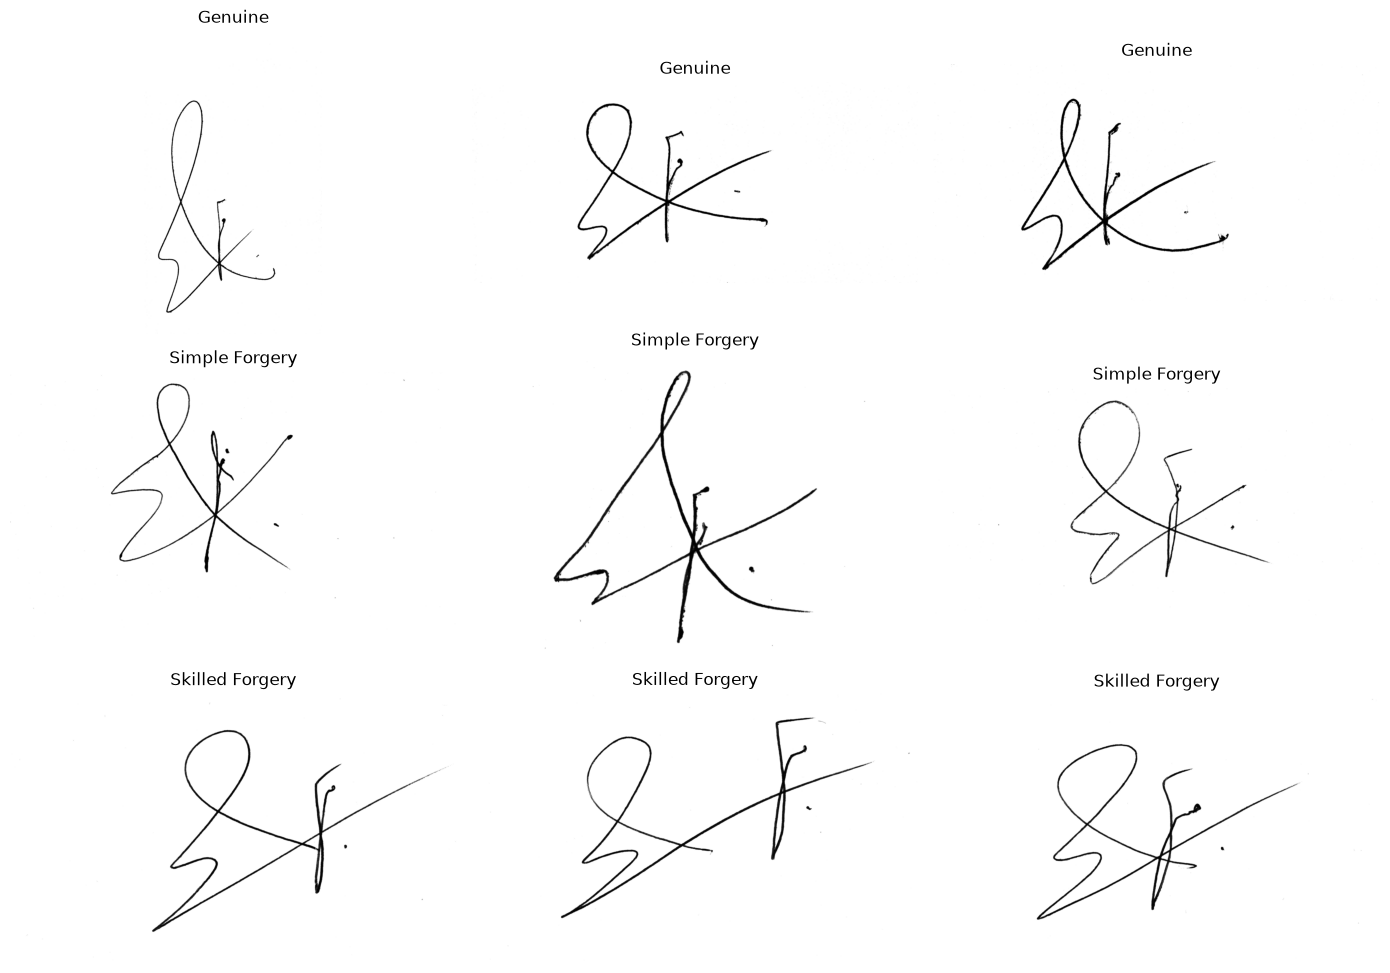

In [43]:
sample_groups = [
    ("Genuine", genuine_samples),
    ("Simple Forgery", simple_samples),
    ("Skilled Forgery", skilled_samples),
]

fig, axes = plt.subplots(
    3,
    3,
    figsize=(14, 10)
)

for row_index, (group_name, group_df) in enumerate(sample_groups):

    for col_index, (_, row) in enumerate(group_df.iterrows()):

        image_path = (
            PROJECT_ROOT
            / row["file_path"]
        )

        img = cv2.imread(
            str(image_path),
            cv2.IMREAD_GRAYSCALE
        )

        ax = axes[row_index, col_index]

        ax.imshow(
            img,
            cmap="gray"
        )

        ax.set_title(
            group_name,
            fontsize=12
        )

        ax.axis("off")


plt.tight_layout()
plt.show()

In [44]:
METADATA_DIR = (
  PROJECT_ROOT / "data" / "metadata"
)

METADATA_DIR.mkdir(parents=True , exist_ok=True)

metadata_path = (
  METADATA_DIR / "metadata.csv"
)

metadata_df.to_csv(metadata_path , index=False , encoding="utf-8-sig")

print("saved :" , metadata_path)

saved : d:\AI\projects\project_02_signature_verification_structure\project_02_signature_verification\data\metadata\metadata.csv


In [47]:
image_stats = []

for _ , row in metadata_df.iterrows():
  
  image_path = PROJECT_ROOT / row["file_path"]
  
  img = cv2.imread(
    str(image_path),
    cv2.IMREAD_GRAYSCALE
  )
  
  if img is None:
    continue
  
  height , width = img.shape
  
  aspect_ratio  = width / height
  
  ink_pixels = np.sum(img<200)
  
  ink_density = (
    ink_pixels / img.size
  )
  
  image_stats.append({
    "file_path": row["file_path"],
    "writer_id": row["writer_id"],
    "signature_type": row["signature_type"],
    "width": width,
    "height": height,
    "aspect_ratio": aspect_ratio,
    "ink_density": ink_density
  })
  
image_stats_df = pd.DataFrame(image_stats)

image_stats_df.head()
  

,file_path,writer_id,signature_type,width,height,aspect_ratio,ink_density
0,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,1,genuine,1135,1142,0.993870,0.033965
1,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,1,genuine,1234,2051,0.601658,0.017481
2,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,1,genuine,2180,986,2.210953,0.015270
3,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,1,genuine,2196,986,2.227181,0.014357
4,data\raw\utsig\UTSig_FullSize\UTSig_FullSize\G...,1,genuine,924,1282,0.720749,0.044021


In [49]:
image_stats_df.describe()

,writer_id,width,height,aspect_ratio,ink_density
count,7934.000000,7934.000000,7934.000000,7934.000000,7934.000000
mean,58.006806,1758.353290,1077.428787,1.667407,0.024356
std,33.195033,506.191463,290.698569,0.410960,0.016863
min,1.000000,370.000000,264.000000,0.449927,0.002018
25%,29.000000,1305.000000,927.000000,1.569422,0.012193
50%,58.000000,2059.000000,1149.000000,1.677245,0.017967
75%,87.000000,2163.000000,1289.000000,1.872962,0.033388
max,115.000000,2858.000000,2058.000000,5.346290,0.108455


In [53]:
print("unique widths :" , image_stats_df["width"].unique())

print("Unique heights:",image_stats_df["height"].nunique())

print("Min width:",image_stats_df["width"].min())

print("Max width:",image_stats_df["width"].max())

print("Min height:",image_stats_df["height"].min())

print("Max height:",image_stats_df["height"].max())

unique widths : [1135 1234 2180 ... 2013 1860 1965]
Unique heights: 1028
Min width: 370
Max width: 2858
Min height: 264
Max height: 2058


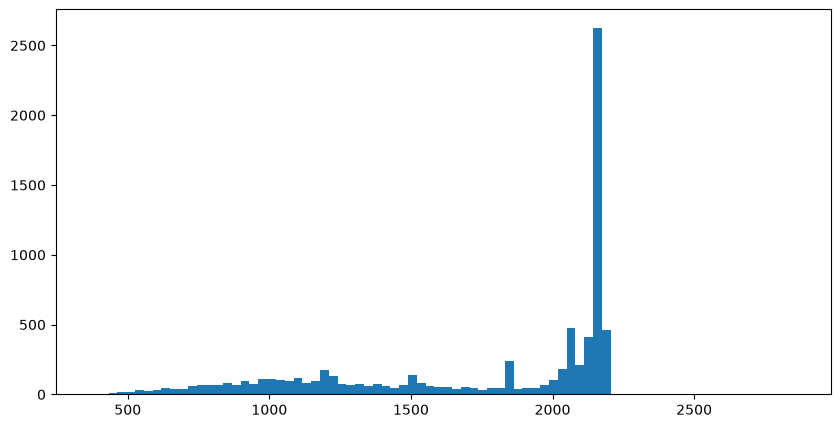

In [61]:
#اینو برای مقیاس عرض هر عکس گرفتم
plt.figure(figsize=(10 , 5))

plt.hist(
  image_stats_df["width"],
  bins=80
)

plt.title = ("Image Width Distribution")

plt.xlabel = ("width")

plt.ylabel = ("Count")

plt.show()

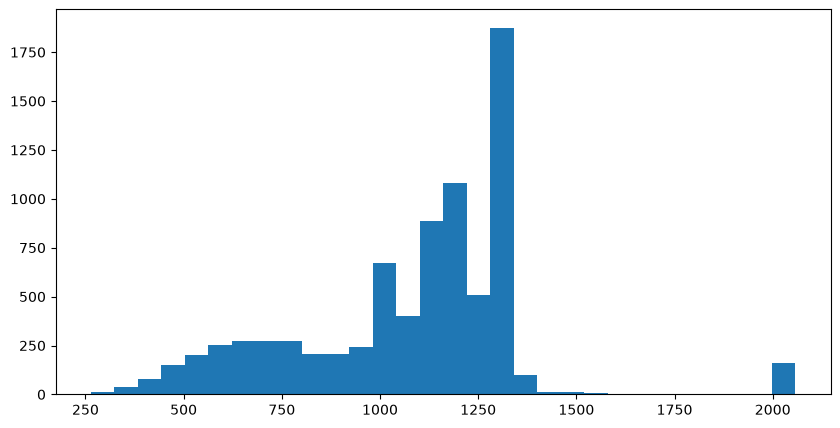

In [62]:
#اینو برای مقیاس ارتفاع هر عکس گرفتم

plt.figure(figsize=(10 ,5))

plt.hist(image_stats_df["height"] , bins=30)

plt.title = "Image Height Distribution"

plt.xlabel = "Height"

plt.ylabel = "Count"

plt.show()

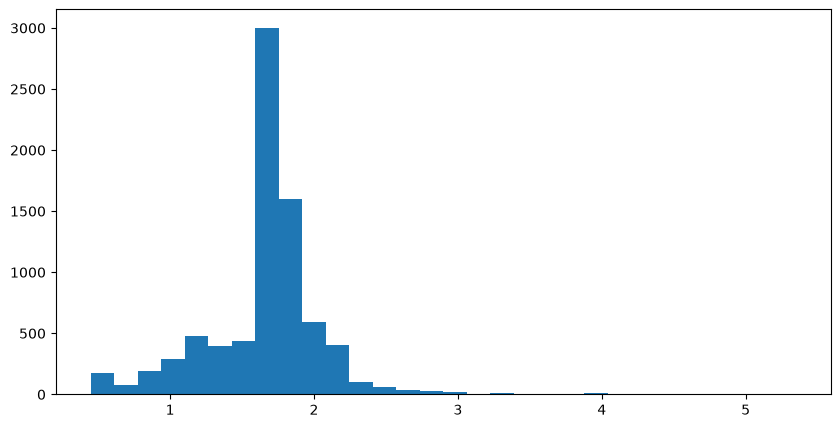

In [64]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    image_stats_df["aspect_ratio"],
    bins=30
)

plt.title = (
    "Signature Aspect Ratio Distribution"
)

plt.xlabel = (
    "Width / Height"
)

plt.ylabel = (
    "Count"
)

plt.show()

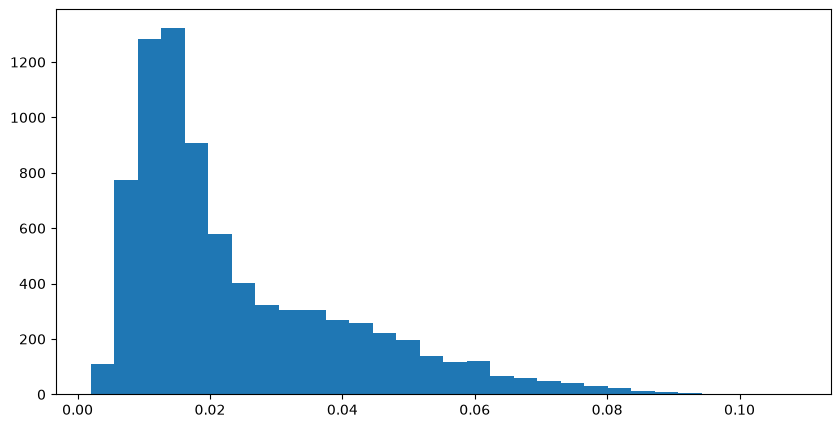

In [65]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    image_stats_df["ink_density"],
    bins=30
)

plt.title = (
    "Ink Density Distribution"
)

plt.xlabel = (
    "Ink Density"
)

plt.ylabel = (
    "Count"
)

plt.show()

In [66]:
image_stats_df.groupby("signature_type")[
  [
    "width",
    "height",
    "aspect_ratio",
    "ink_density"
  ]
].mean()

,width,height,aspect_ratio,ink_density
signature_type,,,,
genuine,1313.945572,895.634138,1.585444,0.036665
simple_forgery,2041.758454,1189.225604,1.726492,0.016252
skilled_forgery,2058.191582,1224.937591,1.681743,0.017582


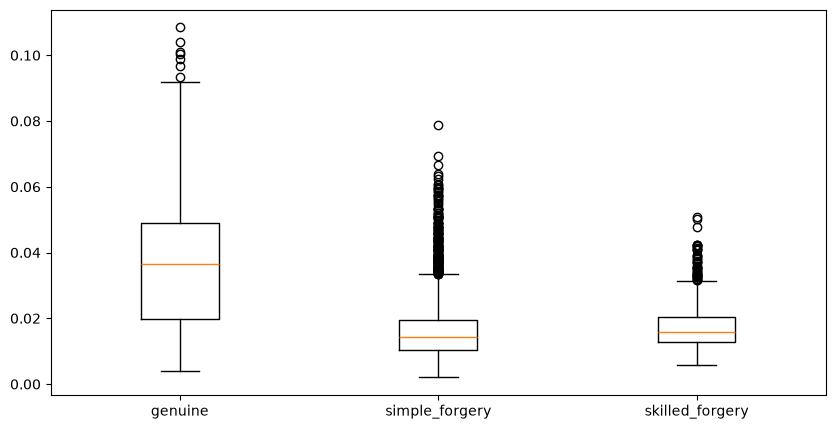

In [68]:
groups = [
    "genuine",
    "simple_forgery",
    "skilled_forgery"
]

data = [
    image_stats_df[
        image_stats_df["signature_type"] == group
    ]["ink_density"]
    for group in groups
]

plt.figure(
    figsize=(10, 5)
)

plt.boxplot(
    data,
    tick_labels=groups
)

plt.title = (
    "Ink Density by Signature Type"
)

plt.ylabel = (
    "Ink Density"
)

plt.show()